# Week 1 

This notebooks goal is to quickly test the dynamic transition model and compare it to the previous models

In [1]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import jax 
jax.config.update("jax_enable_x64", True) 

In [2]:
from src.api.v4.transitions.dynamic_transition import DynamicTransition 
from src.api.v4.transitions.static_transition import StaticTransition
from src.api.v4.emissions.gauss_emission import GaussEmission 
from src.api.v4.hmm_models.hmm import HMM
from src.api.v4.utils import load_y_data
from src.data import load_and_aggregate_data

In [3]:
data = load_and_aggregate_data()
ys = load_y_data() 
data

,HalfHour,CO2C,WindowClosed,Time,Day,Month,Hour
0,24,501.640625,0.5,0.020833,18.0,3.0,12.0
1,25,636.562500,1.0,0.041667,18.0,3.0,12.5
2,26,636.562500,1.0,0.062500,18.0,3.0,13.0
3,27,626.875000,1.0,0.083333,18.0,3.0,13.5
4,28,536.145833,1.0,0.104167,18.0,3.0,14.0
...,...,...,...,...,...,...,...
1661,5,1299.583333,1.0,34.625000,22.0,4.0,2.5
1662,6,1300.000000,1.0,34.645833,22.0,4.0,3.0
1663,7,1118.645833,1.0,34.666667,22.0,4.0,3.5
1664,8,1269.270833,1.0,34.687500,22.0,4.0,4.0


In [4]:
ys

Array([ 501.640625  ,  636.5625    ,  636.5625    , ..., 1118.64583333,
       1269.27083333, 1239.6875    ], dtype=float64)

## Fitting Ordinary HMM 

In [5]:
frozen_params = {
    "mu0": False
}

mu0 = 400 
q = jnp.quantile(ys, jnp.array([0.40, 0.60, 0.80]))

In [6]:
mu = jnp.concatenate([jnp.array([mu0]), q])
std = jnp.std(ys) * jnp.ones_like(mu)
transition_matrix = jnp.array([[0.7, 0.1, 0.1, 0.1],
                               [0.1, 0.7, 0.1, 0.1],
                               [0.1, 0.1, 0.7, 0.1],
                               [0.1, 0.1, 0.1, 0.7]])

emission = GaussEmission.from_params(mu=mu, sigma=std)

transition_matrix = StaticTransition.from_params(transition_matrix)
model = HMM(transition=transition_matrix, emission=emission)

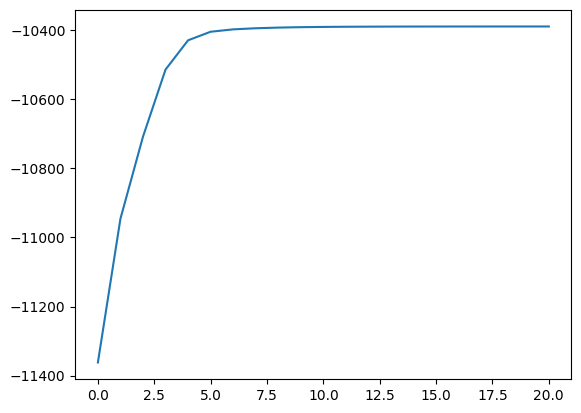

In [7]:
model.fit(ys, frozen=frozen_params)
plt.plot(model.ll_fits)

In [8]:
mu = model.emission.mu(0, ys)
std = model.emission.sigma(0, ys)
transition_matrix = model.transition.transition_matrix(0, ys) 

print("Mu:", mu)
print("----------")
print("Std:", std)
print("----------")
print("Transition matrix:")
for row in transition_matrix:
    print(" ".join(f"{float(v):.2f}" for v in row))

Mu: [ 400.          535.68424024  889.92839567 1306.48367045]
----------
Std: [ 21.74820467  76.5733242  110.98081154 197.4100268 ]
----------
Transition matrix:
0.85 0.15 0.00 0.00
0.08 0.85 0.07 0.00
0.00 0.16 0.68 0.15
0.00 0.00 0.07 0.93


## Fitting Dynamic Transition HMM

In [9]:
import jax.random as random

key = random.PRNGKey(0)
n, m = transition_matrix.shape
beta_vals = random.uniform(key, shape=(2, n, m-1), minval=-1.0, maxval=1.0) * 10
beta_vals

Array([[[-1.63085777, -5.67409091,  9.30642922],
        [ 1.49001067,  0.64452977, -2.90189639],
        [ 7.66017952,  2.65120781,  0.67600153],
        [-6.16692237,  7.08353304, -8.81121418]],

       [[ 2.86783425,  9.88142336,  2.04029229],
        [-2.23367696, -4.06583151,  2.87087761],
        [-1.55361809,  8.67438405,  0.47086957],
        [ 1.12589259,  1.49527552,  0.37271043]]], dtype=float64)

In [10]:

transition_logits = model.transition.transition_logits 
inital_distribution = model._compute_stationary_distribution()
transition = DynamicTransition(transition_logits=transition_logits, beta=beta_vals) 
transition

DynamicTransition(beta=f64[2,4,3], transition_logits=f64[4,3])

In [11]:
inital_distribution

Array([[0.18830282, 0.34137428, 0.1488602 , 0.3214627 ]], dtype=float64)

In [12]:
emission = model.emission 
emission

GaussEmission(log_mu_diff=f64[3], mu0=f64[], log_sigma=f64[4])

Building covariates

In [13]:
time = jnp.asarray(data["HalfHour"], dtype=float)
cos = jnp.cos(2 * jnp.pi * time / 48)
sin = jnp.sin(2 * jnp.pi * time / 48) 
xs = jnp.column_stack((cos, sin)) 

In [14]:
dynamic_model = HMM(transition=transition, emission=emission, inital_distribution=inital_distribution) 

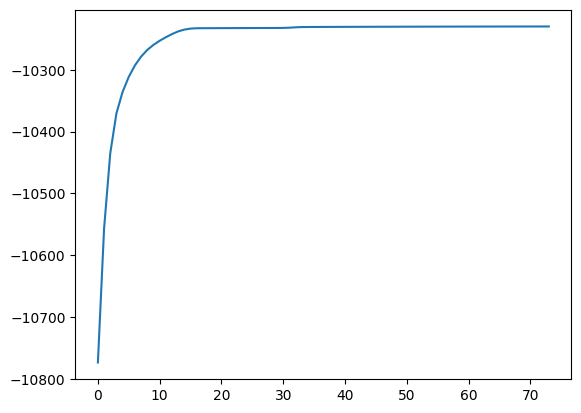

In [15]:
dynamic_model.fit(ys, xs=xs, frozen=frozen_params)
plt.plot(dynamic_model.ll_fits)

In [17]:
mu = dynamic_model.emission.mu(0, ys)
std = dynamic_model.emission.sigma(0, ys)
transition_matrix = dynamic_model.transition.base_transition_matrix()
beta = dynamic_model.transition.beta 

print("Mu:", mu)
print("----------")
print("Std:", std)
print("----------")
print("Transition matrix:")
for row in transition_matrix:
    print(" ".join(f"{float(v):.2f}" for v in row))
print("----------")
print("Beta:")
print(beta)

Mu: [ 400.          546.12162553  892.98438794 1302.65353776]
----------
Std: [ 26.08129359  78.76873531 101.45790495 198.46906274]
----------
Transition matrix:
0.65 0.35 0.00 0.00
0.11 0.85 0.04 0.00
0.00 0.10 0.82 0.08
0.00 0.00 0.00 1.00
----------
Beta:
[[[ 8.76914944e-01  2.91778917e+00  9.65987346e-01]
  [-1.97173646e-01  2.34544888e+00  3.76705842e-01]
  [ 3.17502730e-02 -7.92916459e-01  2.55676936e+00]
  [-1.47404650e+00 -1.16125513e+01 -9.01342409e+00]]

 [[ 2.57550700e+00  4.22610215e+01  4.32763757e+00]
  [ 4.06670892e-01  2.44013180e+00  1.71414271e+00]
  [-9.57874640e-01  5.97616250e-01  1.09187300e+00]
  [-6.81901508e+00 -3.36903126e+01  6.11808696e+00]]]


In [18]:
dynamic_model.transition.transition_logits

Array([[ -0.62603775, -25.19517427, -25.59332466],
       [ -2.03776725,  -3.16543239, -26.9446855 ],
       [-25.13650551,  -2.07740616,  -2.36770413],
       [-25.03133679, -15.00434305, -11.10899543]], dtype=float64)

### Checking Dynamic Model Results

In [19]:
import statsmodels.api as sm

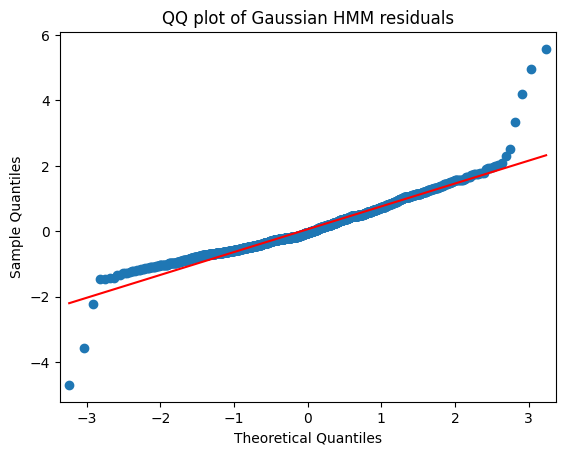

In [20]:
state_results = dynamic_model.state_results 
sm.qqplot(state_results.pseudo_residuals, line='s')
plt.title("QQ plot of Gaussian HMM residuals")
plt.show()

In [21]:
from src.api.v4.hmm_models.utils import AIC, BIC, LRT

static = model.hmm_results 
dynamic = dynamic_model.hmm_results 

print("Static Model Results:")
print(static)

print("Dynamic Model Results:")
print(dynamic)

Static Model Results:
HMMResults(convergence=True, log_likelihood=-10388.866738137815, num_params=20)
Dynamic Model Results:
HMMResults(convergence=True, log_likelihood=-10229.743976932486, num_params=44)


In [22]:
print("AIC for Static Model:", AIC(static))
print("AIC for Dynamic Model:", AIC(dynamic))

AIC for Static Model: 20817.73347627563
AIC for Dynamic Model: 20547.487953864973


In [23]:
num_data_points = len(ys)
print("BIC for Static Model:", BIC(static, num_data_points))
print("BIC for Dynamic Model:", BIC(dynamic, num_data_points))

BIC for Static Model: 20926.097092730164
BIC for Dynamic Model: 20785.88791006495


In [24]:
test_statistic, p_value = LRT(static, dynamic)
print(f"LRT statistic: {test_statistic}, p-value: {p_value}")

LRT statistic: 318.2455224106561, p-value: 0.0


In [28]:
#Printing the tranisition proberbilities over 1 day
time = jnp.arange(0, 24, 0.1)  # Time from 0 to 24 hours in 30-minute intervals
cos = jnp.cos(2 * jnp.pi * time / 24)
sin = jnp.sin(2 * jnp.pi * time / 24)
xs = jnp.column_stack((cos, sin))

#Computing 1 to 4 
transition_matrices = []
for t in range(xs.shape[0]):
    transition_matrix = dynamic_model.transition.transition_matrix(t, xs)
    transition_matrices.append(transition_matrix)  # Get the transition probabilities to state 0



data = jnp.stack(transition_matrices)  # Shape: (num_time_points, num_states)
data.shape

(240, 4, 4)

In [29]:
data = jnp.stack(transition_matrices)  # Shape: (num_time_points, num_states)


def plot_transition_probabilities(time, data, state_index=0):
    _, ax = plt.subplots()
    for i in range(data.shape[2]):  # Iterate over the components (states)
        ax.plot(time, data[:,state_index, i], label=f"S{state_index} to S{i}")

    ax.set_xlabel("time")
    ax.set_ylabel("value")
    ax.legend()
    plt.show()

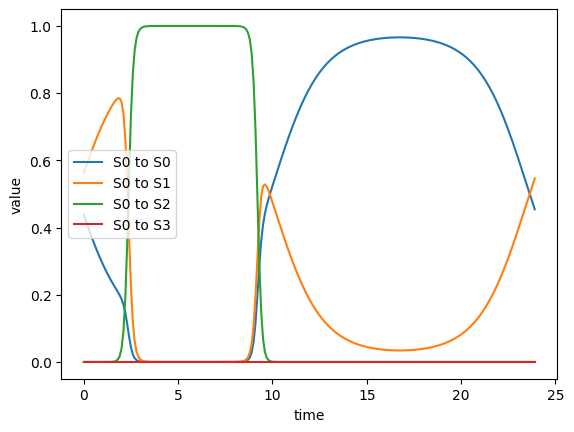

In [30]:
plot_transition_probabilities(time, data, state_index=0)

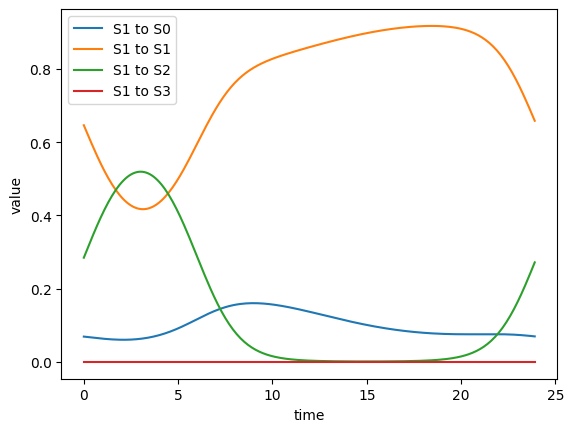

In [31]:
plot_transition_probabilities(time, data, state_index=1)

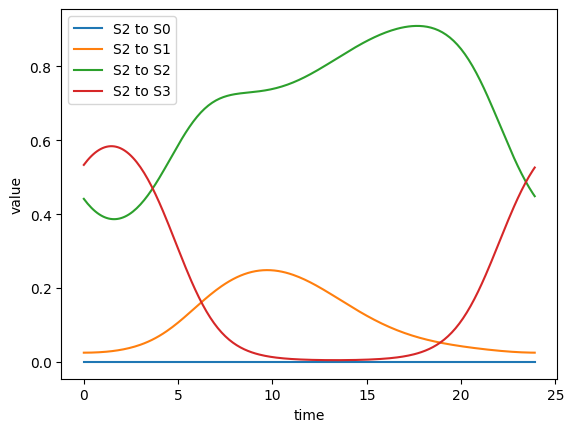

In [32]:
plot_transition_probabilities(time, data, state_index=2)

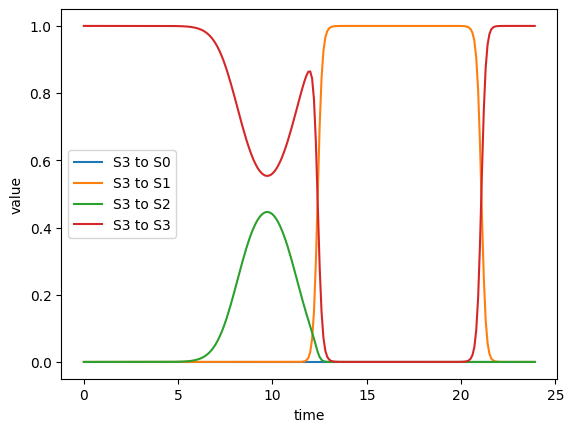

In [33]:
plot_transition_probabilities(time, data, state_index=3)